 ### **Import Libraries**

In [100]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier




 ### **Load Dataset**

In [101]:
df = pd.read_csv(
    "C:/Users/Anshul/Desktop/Flight Delay Prediction/flights.csv",
    low_memory=False,
    nrows=50000   # load only 50000 rows
)

In [102]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY  \
0          -

### **Data Cleaning**

In [103]:
# Drop rows where target is missing
df = df.dropna(subset=['ARRIVAL_DELAY'])

# Fill numeric columns only
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

In [104]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48753 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 48753 non-null  int64  
 1   MONTH                48753 non-null  int64  
 2   DAY                  48753 non-null  int64  
 3   DAY_OF_WEEK          48753 non-null  int64  
 4   AIRLINE              48753 non-null  object 
 5   FLIGHT_NUMBER        48753 non-null  int64  
 6   TAIL_NUMBER          48753 non-null  object 
 7   ORIGIN_AIRPORT       48753 non-null  object 
 8   DESTINATION_AIRPORT  48753 non-null  object 
 9   SCHEDULED_DEPARTURE  48753 non-null  int64  
 10  DEPARTURE_TIME       48753 non-null  float64
 11  DEPARTURE_DELAY      48753 non-null  float64
 12  TAXI_OUT             48753 non-null  float64
 13  WHEELS_OFF           48753 non-null  float64
 14  SCHEDULED_TIME       48753 non-null  int64  
 15  ELAPSED_TIME         48753 non-null  floa

 ### **Delay Distribution**

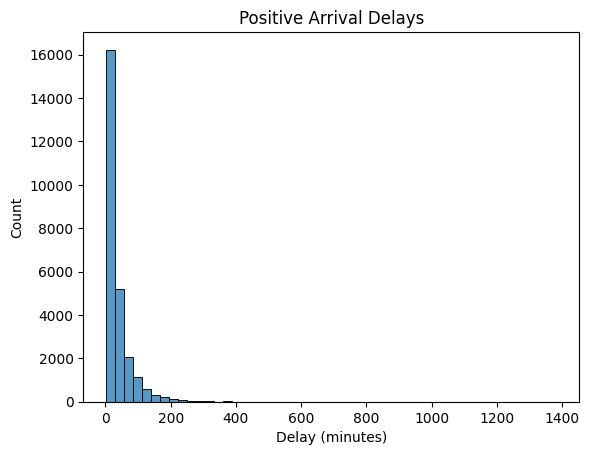

In [106]:
sns.histplot(df[df['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY'], bins=50)

plt.title("Positive Arrival Delays")
plt.xlabel("Delay (minutes)")
plt.show()

### **Delayed vs On time Flights**

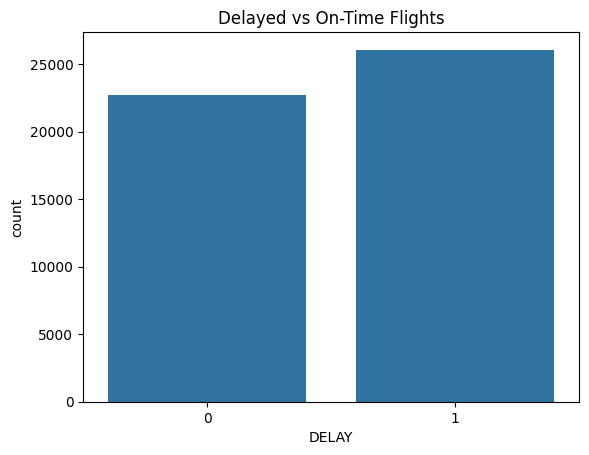

In [107]:
df['DELAY'] = df['ARRIVAL_DELAY'].apply(lambda x: 1 if x > 0 else 0)

sns.countplot(x='DELAY', data=df)

plt.title("Delayed vs On-Time Flights")
plt.show()

### **Delays by Day of Week**

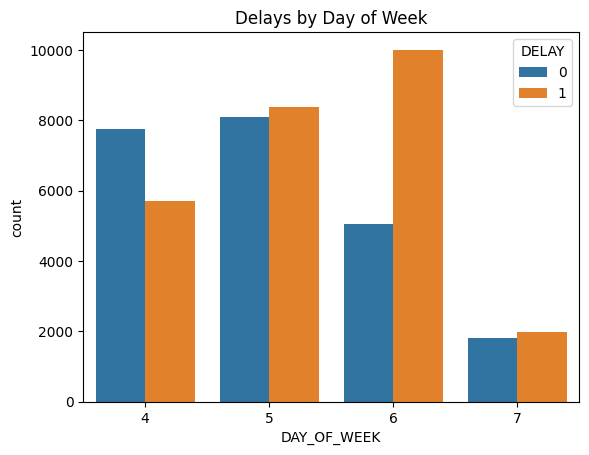

In [108]:
sns.countplot(x='DAY_OF_WEEK', hue='DELAY', data=df)

plt.title("Delays by Day of Week")
plt.show()

### **Departure vs Arrival Delay**

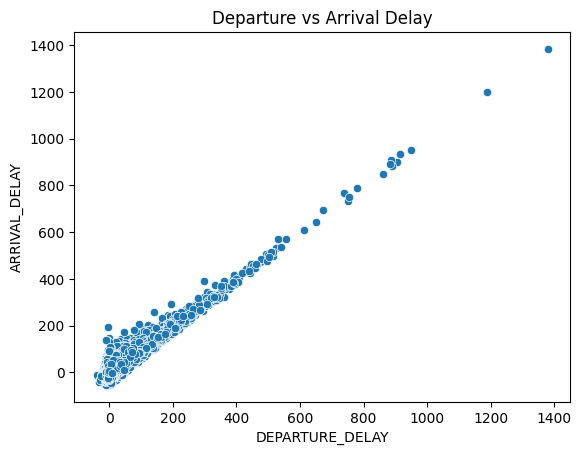

In [112]:
sns.scatterplot(x='DEPARTURE_DELAY', y='ARRIVAL_DELAY', data=df)

plt.title("Departure vs Arrival Delay")
plt.show()

### **Feature Engineering**

In [113]:
df['DELAY'] = df['ARRIVAL_DELAY'].apply(lambda x: 1 if x > 0 else 0)

In [114]:
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(lambda x: 1 if x >= 6 else 0)

### **Feature Selection**

In [115]:
df_model = df[['MONTH','DAY','DAY_OF_WEEK',
               'AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
               'DEPARTURE_DELAY','DISTANCE','IS_WEEKEND','DELAY']].copy()

In [119]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    df_model[col] = le.fit_transform(df_model[col])

In [122]:
X = df_model.drop('DELAY', axis=1)
y = df_model['DELAY']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [123]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
y_pred = model.predict(X_test)

### **Evaluation**

In [125]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044303148395037


In [126]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.90      0.81      4497
           1       0.89      0.72      0.80      5254

    accuracy                           0.80      9751
   macro avg       0.81      0.81      0.80      9751
weighted avg       0.82      0.80      0.80      9751

[[4046  451]
 [1456 3798]]


In [127]:
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(lambda x: 1 if x >= 6 else 0)

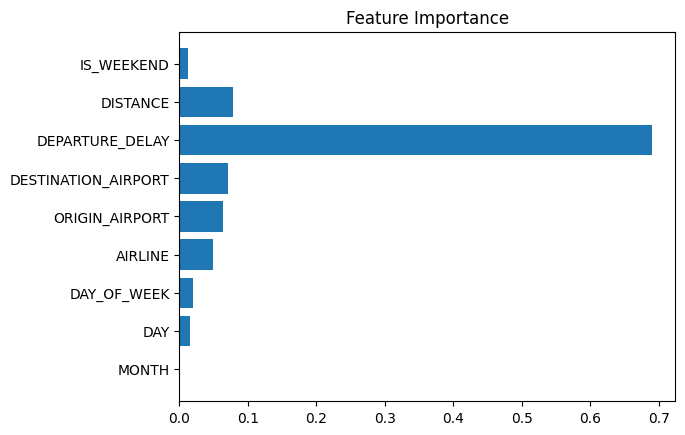

In [130]:

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [131]:
import joblib
joblib.dump(model, "flight_model.pkl")

['flight_model.pkl']